<a href="https://colab.research.google.com/github/melissa-04/melisayla-biyoinformatik/blob/main/notebooks/rna-seq/06_sayim_tablosu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sayım tablosundan analize: sayı yakasına geçiş

FASTQ yakası bitti; bundan sonra tek dosyayla çalışıyoruz: altı örneğin gen düzeyi sayım tablosu. Bu defterde tabloyu tanıyacağız, dördüncü rehberde not ettiğiniz gizemli ENSMUST kodlarının kimliğini açıklayacağız ve veriyi istatistiğin kapısına kadar getireceğiz.

In [1]:
import pandas as pd

t = pd.read_csv('https://raw.githubusercontent.com/melissa-04/melisayla-biyoinformatik/main/data/rna-seq/sayim_tablosu.csv')
print(t.shape[0], 'gen ×', t.shape[1]-2, 'örnek')
t.head()

56065 gen × 6 örnek


,gen_id,gen_adi,WT_1,WT_2,WT_3,KO_1,KO_2,KO_3
0,ENSMUSG00000000001.5,Gnai3,1419,662,2800,2182,2872,2462
1,ENSMUSG00000000003.16,Pbsn,0,0,0,0,0,0
2,ENSMUSG00000000028.16,Cdc45,1654,1099,2770,1155,1891,1299
3,ENSMUSG00000000031.19,H19,26461,23546,74207,19488,32414,45889
4,ENSMUSG00000000037.18,Scml2,37,15,82,10,20,10


## 1. Kütüphane büyüklükleri

Her sütunun toplamı, o örnekte genlere dağıtılan toplam okuma. Veri sayfasındaki uyarıyı hatırlayın: WT_3 iki kat derin dizilenmişti. Sayılarda da öyle mi?

WT_1    13.60
WT_2    11.93
WT_3    32.36
KO_1    12.26
KO_2    18.34
KO_3    13.86
dtype: float64   (milyon okuma)


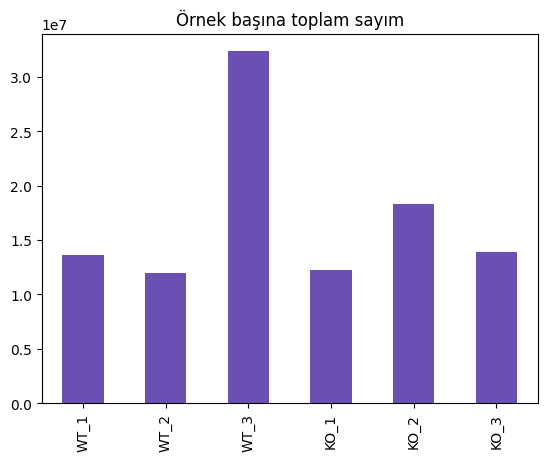

In [2]:
kutuphane = t.drop(columns=['gen_id','gen_adi']).sum()
print((kutuphane / 1e6).round(2), '  (milyon okuma)')
kutuphane.plot(kind='bar', color='#6B4FB3', title='Örnek başına toplam sayım');

## 2. Gizemli transkriptlerin kimliği

Dördüncü rehberde en çok okuma alan ENSMUST kodlarını not etmiştiniz. Sayım tablomuz gen düzeyinde olduğu için o kodlar burada görünmez; kimliklerini GENCODE kataloğundan çözüyoruz. Aşağıdaki listeye kendi not ettiklerinizi de ekleyin.

In [3]:
import gzip, urllib.request

urllib.request.urlretrieve(
    'https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_mouse/release_M35/gencode.vM35.transcripts.fa.gz',
    'gencode.fa.gz')

tx2gen = {}
with gzip.open('gencode.fa.gz', 'rt') as f:
    for satir in f:
        if satir.startswith('>'):
            p = satir[1:].strip().split('|')
            tx2gen[p[0]] = p[5]

merak = ['ENSMUST00000093209.4', 'ENSMUST00000082402.1', 'ENSMUST00000042235.15',
         'ENSMUST00000082405.1', 'ENSMUST00000033229.5', 'ENSMUST00000006749.10']
for kod in merak:
    print(kod, '->', tx2gen.get(kod, 'katalogda yok'))

ENSMUST00000093209.4 -> Hba-a1
ENSMUST00000082402.1 -> mt-Co1
ENSMUST00000042235.15 -> Eef1a1
ENSMUST00000082405.1 -> mt-Co2
ENSMUST00000033229.5 -> Hbb-y
ENSMUST00000006749.10 -> Slc4a1


## 3. Tablonun zirvesi ve dibi

Gen adlarıyla en yüksek toplam sayıma bakalım; fetal karaciğerin ne fabrikası olduğunu tablo kendisi söylüyor. Dibe de bakın: binlerce gen tamamen sıfır. Bu normal; hiçbir doku bütün genleri çalıştırmaz.

In [4]:
toplam = t.set_index(['gen_id','gen_adi']).sum(axis=1).sort_values(ascending=False)
print('En yüksek 10:'); print(toplam.head(10).to_string())
print('\nTamamen sıfır olan gen sayısı:', int((toplam == 0).sum()))

En yüksek 10:
gen_id                 gen_adi
ENSMUSG00000064351.1   mt-Co1     1271988
ENSMUSG00000037742.15  Eef1a1      833573
ENSMUSG00000054932.7   Afp         715411
ENSMUSG00000064354.1   mt-Co2      652249
ENSMUSG00000029368.11  Alb         544393
ENSMUSG00000024661.8   Fth1        543280
ENSMUSG00000050708.17  Ftl1        542837
ENSMUSG00000006574.16  Slc4a1      507021
ENSMUSG00000064370.1   mt-Cytb     491339
ENSMUSG00000064357.1   mt-Atp6     491015

Tamamen sıfır olan gen sayısı: 24448


## 4. İstatistiğin kapısına: biçim ve filtre

PyDESeq2 iki şey ister: satırları örnek, sütunları gen olan bir sayım tablosu ve her örneğin grubunu söyleyen bir künye (metadata). Bir de neredeyse hiç ifade edilmeyen genleri eliyoruz; toplamı 10'un altındaki satırlar istatistiğe gürültüden başka bir şey katmaz.

In [5]:
sayim = t.set_index('gen_id').drop(columns='gen_adi').T
meta = pd.DataFrame({'genotip': ['WT']*3 + ['KO']*3}, index=sayim.index)
sayim = sayim[sayim.columns[sayim.sum(axis=0) >= 10]]
print('Analize giren:', sayim.shape[1], 'gen ×', sayim.shape[0], 'örnek')
meta

Analize giren: 21994 gen × 6 örnek


,genotip
WT_1,WT
WT_2,WT
WT_3,WT
KO_1,KO
KO_2,KO
KO_3,KO


## Kendin dene

Üç görev: kendi not ettiğiniz ENSMUST kodlarını 2. hücredeki listeye ekleyip kimliklerini bulun. WT_3'ün toplamını WT_1'e bölün; kaç kat? Bu sayı, "ham sayılar neden doğrudan karşılaştırılamaz" sorusunun cevabıdır ve bir sonraki rehberin ilk cümlesi olacak. Son olarak `t[t.gen_adi == 'Hbb-bs']` satırına bakın ve Veri sayfasındaki globin uyarısını hatırlayın: bu sayı neden düşük ve neden ona güvenmiyoruz?